In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
import numpy as np
import matplotlib.pyplot as plt

class MiniFlappy:
    """ A container where we package everything """

    # 1. Canvas Dimensions
    SIZE = 32  # 32x32 resolution gives 3,072 values per frame
    
    # 2. Color Palette (normalized float32 values between 0.0 and 1.0)
    BG_COLOR   = np.array([0.08, 0.08, 0.16], dtype=np.float32)  # Dark navy sky
    BIRD_COLOR = np.array([1.00, 1.00, 0.00], dtype=np.float32)  # High-contrast bright yellow
    PIPE_COLOR = np.array([0.10, 0.80, 0.25], dtype=np.float32)  # Vibrant green
    
    # 3. Bird Geometry
    BIRD_X = 8      # Bird is pinned horizontally at column 8
    BIRD_SIZE = 2   # 2x2 pixel footprint
    
    # 4. Pipe Geometry
    PIPE_WIDTH = 3
    GAP_SIZE = 9 

    # 5. Physics Constants
    GRAVITY = 0.3
    FLAP_STRENGTH = -1.2
    MAX_SPEED = 3.0


    def __init__(self, seed=None):
        self.rng = np.random.default_rng(seed)
        self.reset()
        
    def reset(self):
        self.t = 0
        # Start bird near vertical center
        self.bird_y = float(self.SIZE // 2)
        
        # --- FIX 1: Initialize bird velocity so it exists on step 0 ---
        self.bird_vel = 0.0
        
        self.pipe_x = float(self.SIZE - 1)

        # Pick random gap vertical position
        max_gap_y = self.SIZE - 4 - self.GAP_SIZE
        self.gap_y = self.rng.integers(4, max_gap_y + 1)
        return self.observe()

    def _spawn_pipe(self):
        """Brings a new pipe with random gap between rows 4 and max_gap."""
        self.pipe_x = float(self.SIZE - 1)
        max_gap_y = self.SIZE - 4 - self.GAP_SIZE
        self.gap_y = self.rng.integers(4, max_gap_y + 1)
        
    def update_pipe(self):
        """Scroll the pipe leftward by 1 pixel."""
        self.pipe_x -= 1.0

        # If the pipe has completely scrolled off the screen to the left:
        if self.pipe_x + self.PIPE_WIDTH <= 0:
            self._spawn_pipe()

    def update_bird(self, action):
        """Applies flap impulse, gravity, and updates bird position."""
        if action == 1:
            self.bird_vel = self.FLAP_STRENGTH
            
        # --- FIX 2: Replaced the dot with a comma between the speed limits ---
        self.bird_vel = float(np.clip(self.bird_vel + self.GRAVITY, -self.MAX_SPEED, self.MAX_SPEED))
        self.bird_y += self.bird_vel

        # Floor and ceiling collision
        max_y = float(self.SIZE - self.BIRD_SIZE)
        if self.bird_y < 0.0:
            self.bird_y = 0.0
            self.bird_vel = 0.0
        elif self.bird_y > max_y:
            self.bird_y = max_y
            self.bird_vel = 0.0


    def step(self, action):
        """
        Advances the world by 1 frame given an action.
        Returns: (next_observation, done)
        """
        self.update_bird(action)
        self.update_pipe()
        self.t += 1
        
        # Episode ends after 100 steps (for clean, fixed-length trajectories)
        done = self.t >= 100
        
        return self.observe(), done
 


    def observe(self):
        """Renders the current state into a (32, 32, 3) float32 RGB image."""
        # 1. Empty sky canvas
        frame = np.full((self.SIZE, self.SIZE, 3), self.BG_COLOR, dtype=np.float32)
        
        # 2. Render pipes (if visible on screen)
        px = int(round(self.pipe_x))
        x_start = max(0, px)
        x_end = min(self.SIZE, px + self.PIPE_WIDTH)

        if x_start < x_end:
            # Top pipe: row 0 to gap_y
            frame[0:self.gap_y, x_start:x_end] = self.PIPE_COLOR
            # Bottom pipe: from bottom of gap down to floor
            frame[self.gap_y + self.GAP_SIZE:self.SIZE, x_start:x_end] = self.PIPE_COLOR

        # 3. Render bird (clamped bounds)
        yi = int(round(self.bird_y))
        xi = int(self.BIRD_X)
        
        y_min = max(0, yi)
        y_max = min(self.SIZE, yi + self.BIRD_SIZE)
        x_min = max(0, xi)
        x_max = min(self.SIZE, xi + self.BIRD_SIZE)
        
        frame[y_min:y_max, x_min:x_max] = self.BIRD_COLOR

        return frame


### Phase 2 : Step 1.2 we are going to record 200 episodes with 100 steps 

In [9]:

## Parameter to record the seesion 
EPISODES = 200
T = 100
SIZE = 32 
SEED = 42

env  = MiniFlappy(seed=SEED)
rng = np.random.default_rng(SEED)






## Allocting empty spaces to store the frames 
frames = np.zeros((EPISODES,T,SIZE,SIZE,3),dtype=np.float32)
## allocating emplty spaces to store the actions
actions = np.zeros((EPISODES,T),dtype=np.int64)


print(f"recording {EPISODES} episodes of {T} steps each ............. ")

for e in range(EPISODES):
    
    # at the start of every episode , hit a "new game"

    obs = env.reset()

    for t in range(T):


        # taking an action 18 % time ("1 ") and 82 time ("0")

        a = 1 if (rng.random() < 0.18) else 0 


        # store the current photo and action in our albums
        frames[e,t] = obs
        actions[e,t] = a


        # move the world forward by 1 frame 
        obs , done = env.step(a)

print("collection completed! ")



recording 200 episodes of 100 steps each ............. 
collection completed! 


In [12]:
print(f" data shepe : {np.shape(frames)}")
print(f"Memory used  : {frames.nbytes / (1024 * 1024):.1f} MB")

 data shepe : (200, 100, 32, 32, 3)
Memory used  : 234.4 MB


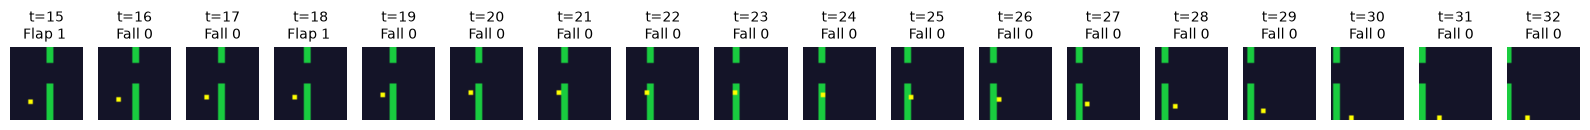

In [21]:
e_to_view = 10
start_step = 15 
num_frames = 18


fig,axes = plt.subplots(1,num_frames, figsize=(16,3))

for i in range(num_frames):
    t = start_step+i 
    img = frames[e_to_view,t]
    act = actions[e_to_view,t]

    act_label = "Flap 1 " if act == 1 else "Fall 0"



    axes[i].imshow(img)
    axes[i].set_title(f"t={t}\n{act_label}", fontsize=10)
    axes[i].axis("off")
    

plt.tight_layout()
plt.show()

### The vision model ``{ V }`` of or world model  `Variational Autoencoder`

  Raw Image               Compressed Code              Reconstructed Image
 (3,072 numbers)         (just 32 numbers!)             (3,072 numbers)
 
   [PHOTO]   ────► [ ENCODER ] ────► [ z ] ────► [ DECODER ] ────► [RE-DRAWN PHOTO]


Input Frame:         32 x 32 pixels  (3 color channels)
         │  Conv layer 1 (stride 2)
         ▼
First fold:          16 x 16 features (32 filters)
         │  Conv layer 2 (stride 2)
         ▼
Second fold:          8 x 8 features  (64 filters)
         │  Conv layer 3 (stride 2)
         ▼
Third fold:           4 x 4 features  (128 filters)
         │  Flatten & Linear layer
         ▼
The Summary Code:    Just 32 numbers! (Latent vector z)


In [24]:
import torch


In [26]:

# changing all the EPISODES and steps into of giant photos 
all_frames = torch.tensor(frames,dtype=torch.float32)
all_frames = all_frames.reshape(-1,32,32,3)
all_frames = all_frames.permute(0,3,1,2)

print(f"original numpy dataset shape : " ,  frames.shape)
print("pytorch training tensor shape :  " , all_frames.shape)


original numpy dataset shape :  (200, 100, 32, 32, 3)
pytorch training tensor shape :   torch.Size([20000, 3, 32, 32])


In [28]:
print("device available :","curd (GPU)" if  torch.cuda.is_available() else "cpu")

device available : cpu
